In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_path="/content/drive/MyDrive/data/dataset/Train"
test_path="/content/drive/MyDrive/data/dataset/Test"

In [3]:
# create a funtion for show images
def plot_images(image_arr):
  fix,axes=plt.subplots(1,10,figsize=(20,20))
  axes=axes.flatten()
  for img,ax in zip(image_arr,axes):
    ax.imshow(img)

  plt.tight_layout()
  plt.show()

## model train

In [4]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras import regularizers

model = Sequential()

# Convolutional Layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

# Fully Connected Layers
model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.30))

# Output Layer
model.add(Dense(1, activation='sigmoid'))  # Single unit with sigmoid activation

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Assuming your training and validation data are stored in directories
train_data_dir = '/content/drive/MyDrive/data/dataset/Train'
val_data_dir = '/content/drive/MyDrive/data/dataset/Test'

train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/data/dataset/Train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'  # Use 'binary' for binary classification
)

validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/data/dataset/Test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Found 416 images belonging to 2 classes.
Found 134 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 74s 5s/step - accuracy: 0.6763 - loss: 8.6062 - val_accuracy: 0.6797 - val_loss: 8.7732
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.7645 - loss: 8.4603 - val_accuracy: 0.6562 - val_loss: 7.9915
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8625 - loss: 7.3758 - val_accuracy: 0.6250 - val_loss: 6.8584
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8741 - loss: 6.2211 - val_accuracy: 0.3516 - val_loss: 5.9480
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8709 - loss: 5.3692 - val_accuracy: 0.3047 - val_loss: 5.4290
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9129 - loss: 4.6165 - val_accuracy: 0.3203 - val_loss: 5.3507
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9073 - loss: 4.1101 - val_accuracy: 0.3281 - val_loss: 4.8532
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9120 - loss: 3.6912 - val_accuracy: 0.3203 - val_loss:

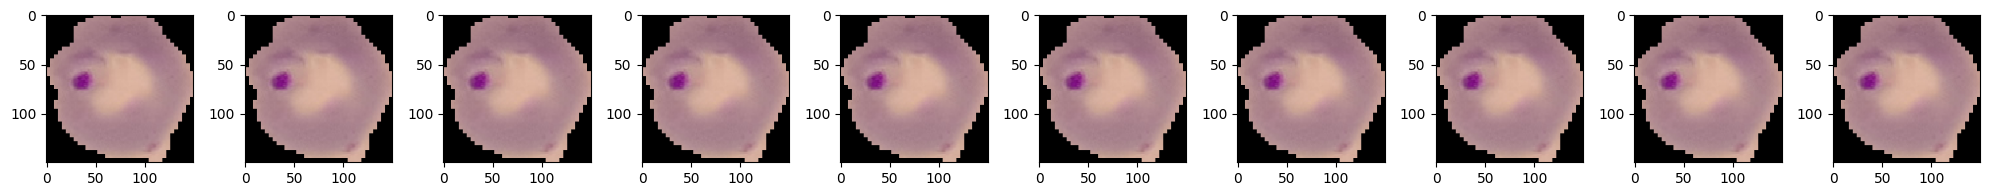

In [5]:
# show images 5

images=[train_generator[0][0][0] for i in range(10)]
plot_images(images)

In [9]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
img_path = "/content/drive/MyDrive/data/dataset/Test/Parasite/C39P4thinF_original_IMG_20150622_105554_cell_10.png"
img = image.load_img(img_path, target_size=(150, 150))  # Resize as per your model input
img_array = image.img_to_array(img)
img_array = img_array / 255.0   # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Predict
probability = model.predict(img_array)[0][0]  # For binary classification with sigmoid

# Threshold
threshold = 0.5
if probability > threshold:
    print("🦠 Tumor/Parasite Detected (Positive)")
else:
    print("✅ No Tumor/Parasite Detected (Negative)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
🦠 Tumor/Parasite Detected (Positive)
